In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

``Part 1``

In [3]:
movies.shape

(9742, 3)

In [4]:
ratings_matrix = ratings.pivot_table(
    index='userId', columns='movieId', values='rating'
).fillna(0)

print(ratings_matrix.shape)

(610, 9724)


In [5]:
movie_rating_counts = ratings.groupby('movieId')['rating'].count().reset_index()
movie_rating_counts.columns = ['movieId', 'num_ratings']

In [6]:
# Merge with movie titles
top_movies = movie_rating_counts.merge(movies, on='movieId') \
    .sort_values('num_ratings', ascending=False) \
    .head(3)[['title', 'num_ratings']]

In [7]:
print(top_movies)

                                title  num_ratings
314               Forrest Gump (1994)          329
277  Shawshank Redemption, The (1994)          317
257               Pulp Fiction (1994)          307


In [8]:
# Count how many movies each user rated
user_rating_counts = ratings.groupby('userId')['rating'].count().reset_index()
user_rating_counts.columns = ['userId', 'num_rated']

top_users = user_rating_counts.sort_values('num_rated', ascending=False).head(3)

In [9]:
print(top_users)

     userId  num_rated
413     414       2698
598     599       2478
473     474       2108


``Part 2``

*a) Creating and plotting the clusters*

In [10]:
k_values = [2, 4, 8, 16, 32, 64, 128]
inertia = []

In [11]:
## This process may take a little bit more time to run compared to the other cells

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(ratings_matrix)
    inertia.append(kmeans.inertia_)
    print(f"k={k}, inertia={kmeans.inertia_}")

/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


k=2, inertia=1094638.7491524713


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


k=4, inertia=1038208.3170919628


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


...

k=32, inertia=775829.9352810743


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


k=64, inertia=621950.3051226645


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


k=128, inertia=415874.785704961


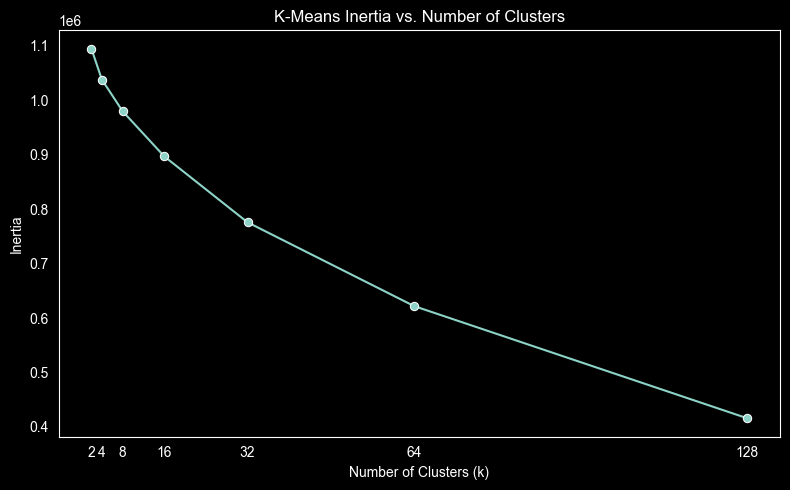

In [12]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=k_values, y=inertia, marker='o')
plt.grid(False)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('K-Means Inertia vs. Number of Clusters')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

*c) chosen cluster*

In [13]:
best_k = 16

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(ratings_matrix)

ratings_matrix_clustered = ratings_matrix.copy()
ratings_matrix_clustered['cluster'] = cluster_labels

/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [15]:
# For each cluster, find the top 3 highest-rated movies
for cluster_id in range(best_k):
    cluster_data = ratings_matrix_clustered[
        ratings_matrix_clustered['cluster'] == cluster_id
    ].drop(columns='cluster')

    # Average rating per movie across users in this cluster
    avg_ratings = cluster_data.mean(axis=0).dropna()

    # Getting top 3 movie IDs
    top3_ids = avg_ratings.nlargest(3).index.tolist()

    # Map to the titles
    top3_titles = movies[movies['movieId'].isin(top3_ids)][['movieId', 'title']]

    print(f"\nCluster {cluster_id} (n={cluster_data.shape[0]} users):")
    for mid in top3_ids:
        title = movies.loc[movies['movieId'] == mid, 'title'].values
        avg = avg_ratings[mid]
        print(f"  {title[0] if len(title) > 0 else mid} — avg rating: {avg}")


Cluster 0 (n=93 users):
  Forrest Gump (1994) — avg rating: 3.263440860215054
  Pulp Fiction (1994) — avg rating: 3.2580645161290325
  Apollo 13 (1995) — avg rating: 3.252688172043011

Cluster 1 (n=1 users):
  Sense and Sensibility (1995) — avg rating: 5.0
  Dead Man Walking (1995) — avg rating: 5.0
  Shawshank Redemption, The (1994) — avg rating: 5.0

Cluster 2 (n=280 users):
  Shawshank Redemption, The (1994) — avg rating: 1.292857142857143
  Matrix, The (1999) — avg rating: 1.2321428571428572
  Star Wars: Episode IV - A New Hope (1977) — avg rating: 1.0767857142857142

Cluster 3 (n=3 users):
  Star Wars: Episode V - The Empire Strikes Back (1980) — avg rating: 4.833333333333333
  Office Space (1999) — avg rating: 4.833333333333333
  American History X (1998) — avg rating: 4.666666666666667

Cluster 4 (n=99 users):
  Matrix, The (1999) — avg rating: 3.388888888888889
  Fight Club (1999) — avg rating: 3.3333333333333335
  Shawshank Redemption, The (1994) — avg rating: 3.2525252525252

``Part 3``

*a) Transpose and Mean Center*

In [16]:
movie_user_matrix = ratings_matrix.T  # shape: (9724, 610)
movie_user_centered = movie_user_matrix.subtract(movie_user_matrix.mean(axis=1), axis=0)

print(movie_user_centered.shape)

(9724, 610)


*b) PCA*

In [17]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(movie_user_centered)

# Build the results dataframe
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'movieId': movie_user_matrix.index
})

# Merging on movies to get genres
pca_df = pca_df.merge(movies[['movieId', 'title', 'genres']], on='movieId')

# Extract only the first genre only
pca_df['first_genre'] = pca_df['genres'].apply(
    lambda x: x.split('|')[0] if x != '(no genres listed)' else 'Unknown'
)

print(pca_df['first_genre'].value_counts())

first_genre
Comedy         2776
Drama          2218
Action         1828
Adventure       652
Crime           534
Horror          468
Documentary     385
Animation       297
Children        197
Thriller         83
Sci-Fi           62
Mystery          48
Fantasy          42
Romance          38
Unknown          34
Western          23
Musical          23
Film-Noir        12
War               4
Name: count, dtype: int64


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid val

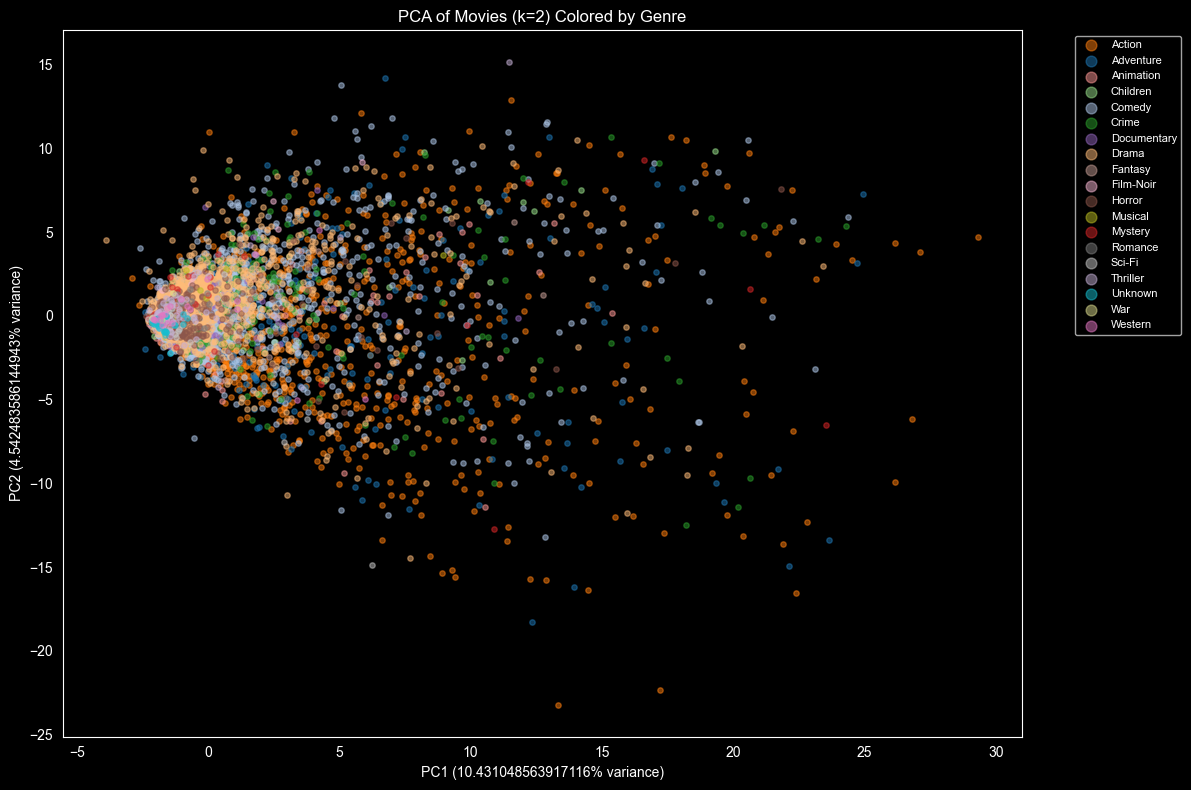

In [18]:
genres = pca_df['first_genre'].unique()
palette = sns.color_palette('tab20', n_colors=len(genres))
color_map = dict(zip(genres, palette))

plt.figure(figsize=(12, 8))
for genre, group in pca_df.groupby('first_genre'):
    plt.scatter(
        group['PC1'], group['PC2'],
        label=genre,
        color=color_map[genre],
        alpha=0.5,
        s=15
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:}% variance)')
plt.title('PCA of Movies (k=2) Colored by Genre')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2, fontsize=8)
plt.grid(False)
plt.tight_layout()
plt.show()

*c) PCA Full*

In [19]:
pca_full = PCA(random_state=42)
pca_full.fit(movie_user_centered)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Components needed for 80% and 40% variance
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_40 = np.argmax(cumulative_variance >= 0.40) + 1

print(f"Components needed for 80% variance: {n_80}")
print(f"Components needed for 40% variance: {n_40}")

Components needed for 80% variance: 165
Components needed for 40% variance: 25


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


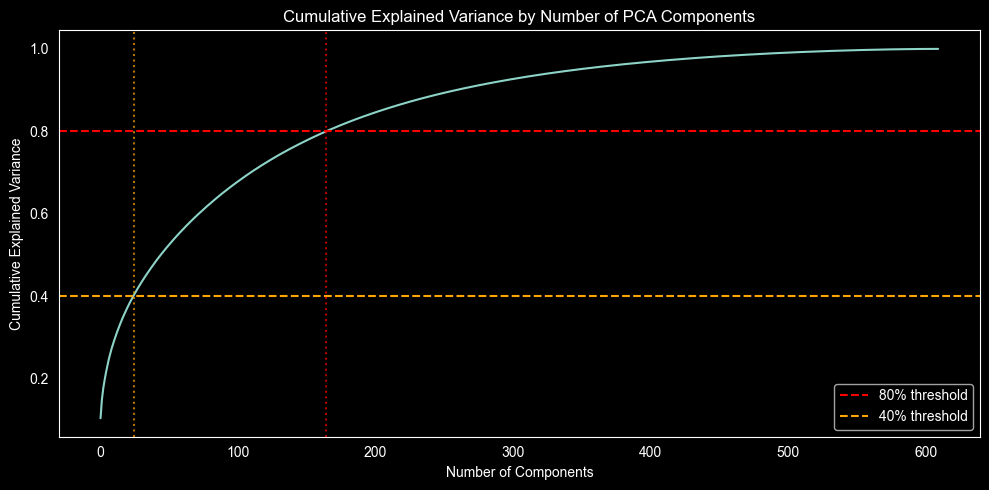

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, linewidth=1.5)
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.axhline(y=0.40, color='orange', linestyle='--', label='40% threshold')
plt.axvline(x=n_80-1, color='red', linestyle=':', alpha=0.7)
plt.axvline(x=n_40-1, color='orange', linestyle=':', alpha=0.7)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Number of PCA Components')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

``Part 4``

*a) Plotting 128 Components*

In [21]:
svd_128 = TruncatedSVD(n_components=128, random_state=42)
svd_128.fit(ratings_matrix)

/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in 

TruncatedSVD(n_components=128, random_state=42)

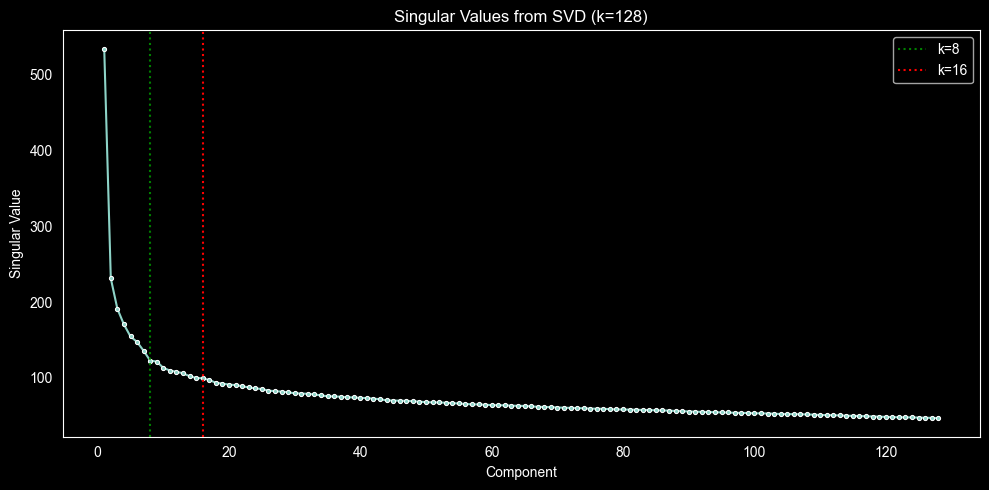

In [22]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 129), y=svd_128.singular_values_, marker='o', markersize=3)
plt.xlabel('Component')
plt.axvline(x=8, color='green', linestyle=':', label='k=8')
plt.axvline(x=16, color='red', linestyle=':', label='k=16')
plt.legend()
plt.grid(False)
plt.ylabel('Singular Value')
plt.title('Singular Values from SVD (k=128)')
plt.tight_layout()
plt.show()

*b) Explained Variance Ratio*

In [23]:
k_values = [2, 4, 8, 16, 32, 64, 128]
evr_sums = []

for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)
    svd.fit(ratings_matrix)
    evr_sums.append(svd.explained_variance_ratio_.sum())
    print(f"k={k}, explained variance ratio sum: {svd.explained_variance_ratio_.sum():}")

/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in 

k=2, explained variance ratio sum: 0.172827017770069
k=4, explained variance ratio sum: 0.22186791013148682


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in 

k=8, explained variance ratio sum: 0.28702917693889535
k=16, explained variance ratio sum: 0.36345368308949694


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in 

...

/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: overflow encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: invalid value encount

k=64, explained variance ratio sum: 0.5876443499054658


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: overflow encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:340: RuntimeWarning: invalid value encount

k=128, explained variance ratio sum: 0.7461262748931874


/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: divide by zero encountered in matmul
  B = Q.T @ M
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: overflow encountered in matmul
  B = Q.T @ M
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:533: RuntimeWarning: invalid value encountered in matmul
  B = Q.T @ M
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/aneesh/Desktop/PyWorks/.venv/lib/pytho

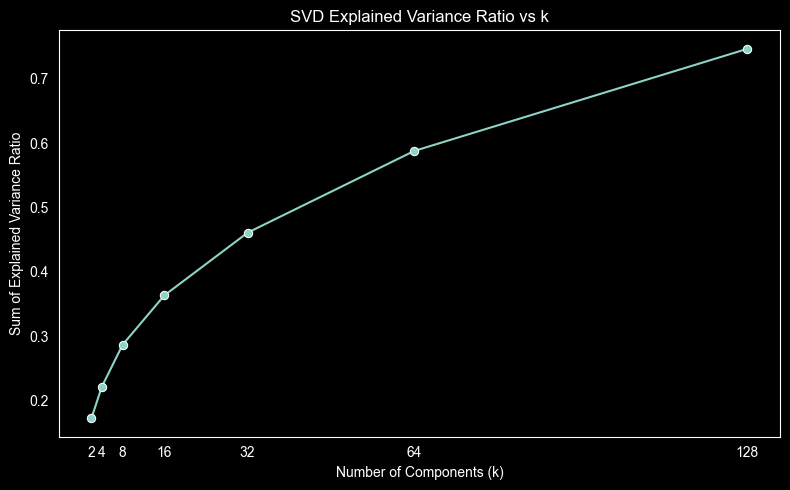

In [24]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=k_values, y=evr_sums, marker='o')
plt.xlabel('Number of Components (k)')
plt.ylabel('Sum of Explained Variance Ratio')
plt.title('SVD Explained Variance Ratio vs k')
plt.xticks(k_values)
plt.grid(False)
plt.tight_layout()
plt.show()

In [25]:
print("\nk | Explained Variance Ratio | Inertia")
for k, evr, inert in zip(k_values, evr_sums, inertia):
    print(f"k={k:<6} EVR={evr:.4f}    Inertia={inert:.2f}")


k | Explained Variance Ratio | Inertia
k=2      EVR=0.1728    Inertia=1094638.75
k=4      EVR=0.2219    Inertia=1038208.32
k=8      EVR=0.2870    Inertia=979812.73
k=16     EVR=0.3635    Inertia=896911.06
k=32     EVR=0.4608    Inertia=775829.94
k=64     EVR=0.5876    Inertia=621950.31
k=128    EVR=0.7461    Inertia=415874.79


*c) Applying SVD with k=2 and transform the data*

In [26]:
svd_2 = TruncatedSVD(n_components=2, random_state=42)
svd_result = svd_2.fit_transform(ratings_matrix)

/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aneesh/Desktop/PyWorks/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in 

In [27]:
svd_df = pd.DataFrame({
    'SVD1': svd_result[:, 0],
    'SVD2': svd_result[:, 1],
    'userId': ratings_matrix.index
})
print(f"SVD k=2 explained variance: {svd_2.explained_variance_ratio_.sum():.4f}")
print(svd_df.head())

SVD k=2 explained variance: 0.1728
        SVD1       SVD2  userId
0  29.689244 -14.261696       1
1   3.135065   4.101635       2
2   0.723193  -0.478282       3
3  17.294912 -12.540399       4
4   6.097046  -5.338220       5


*d) Plot SVD k=2 colored by cluster membership*

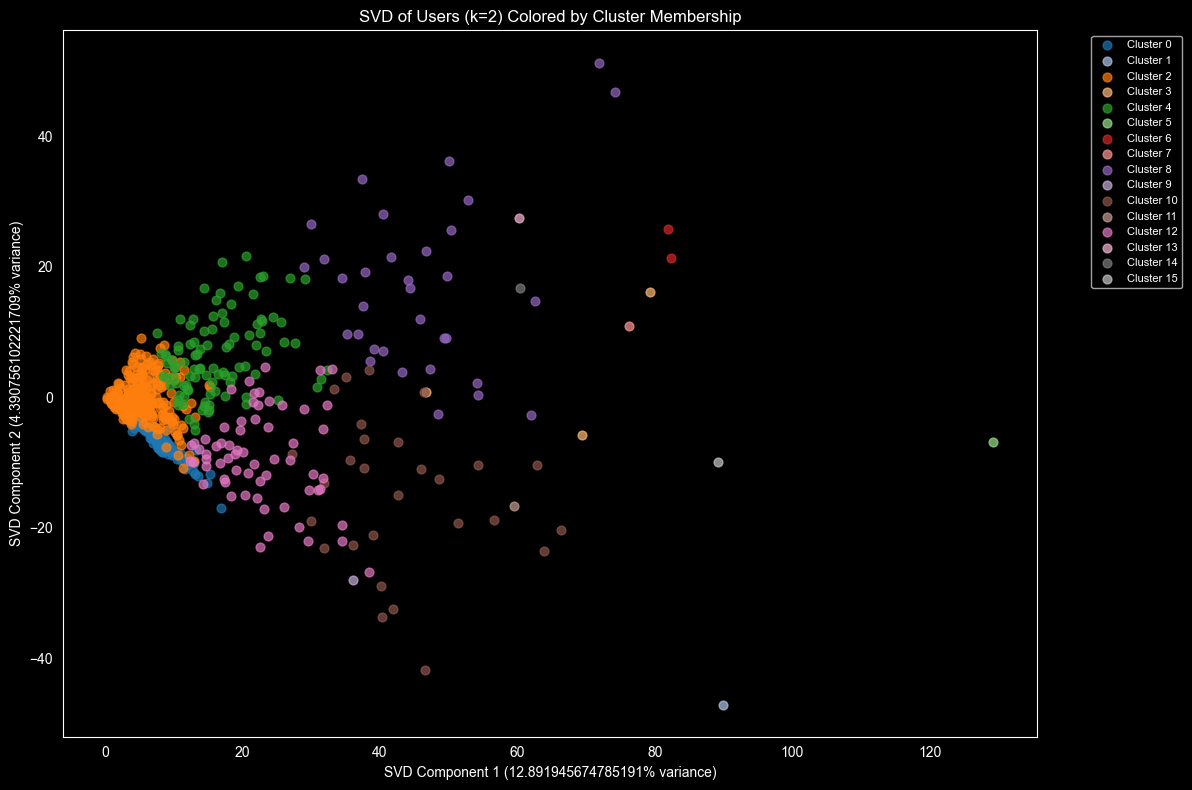

In [28]:
# Add cluster labels from Part 2(c)
svd_df['cluster'] = cluster_labels

# Plot
plt.figure(figsize=(12, 8))
palette = sns.color_palette('tab20', n_colors=best_k)

for cluster_id in range(best_k):
    cluster_data = svd_df[svd_df['cluster'] == cluster_id]
    plt.scatter(
        cluster_data['SVD1'],
        cluster_data['SVD2'],
        label=f'Cluster {cluster_id}',
        color=palette[cluster_id],
        alpha=0.7,
        s=40
    )

plt.xlabel(f'SVD Component 1 ({svd_2.explained_variance_ratio_[0]*100:}% variance)')
plt.ylabel(f'SVD Component 2 ({svd_2.explained_variance_ratio_[1]*100:}% variance)')
plt.title('SVD of Users (k=2) Colored by Cluster Membership')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.grid(False)
plt.show()